<a href="https://colab.research.google.com/github/Ignacioruuizm/EXAMEN_BD_MACHINEL_CSGO/blob/EV1/InformeV2_CounterStrike_FMY0100.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/Ignacioruuizm/BD_CS_MACHINE_LEARNING/blob/main/Informe_Tecnico_FMY0100.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

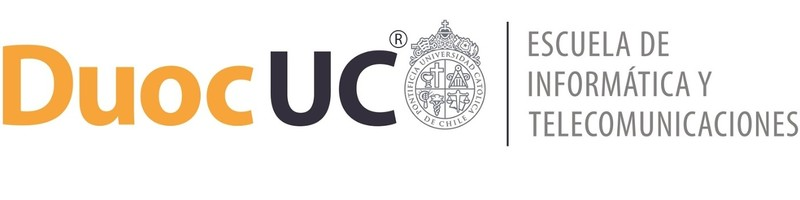

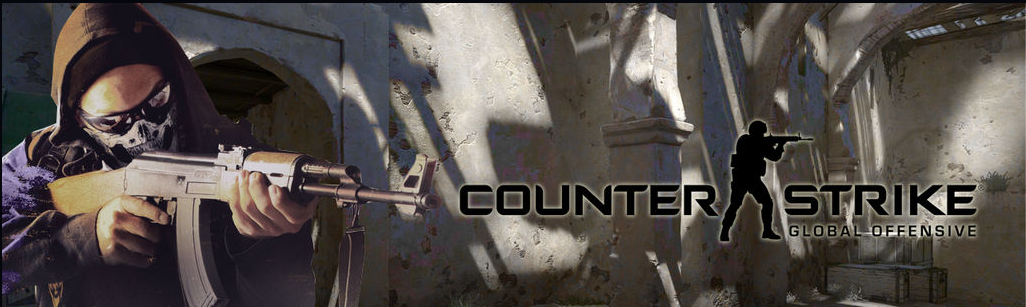

# Informe Técnico - Examen Transversal: Caso Counter Strike


Integrantes:
* Ignacio Ruiz
* Pedro Barrientos
* Pablo Riquelme

Docente: Giocrisrai Godoy

Sección: MLY0100 -

# Caso Fundamentos de Machine Learning

CONTEXTO CASO

Valve, los ha contactado como equipo de análisis de datos y modelado de Machine Learning para analizar y realizar modelos predictivos sobre los datos.

En cada partida de Counter Strike: GO dos equipos de 5 jugadores (denominados terroristas y contra-terroristas) se enfrentan.


El objetivo del equipo terrorista es plantar una bomba con timer de 45 segundos en uno de dos sitios específicos dentro de un mapa. Por otro lado, el objetivo del equipo contra-terrorista es evitar que la bomba sea plantada o desactivarla antes de que esta explote cuando ya ha sido plantada. Los datos a utilizar corresponden a sobre 7000 partidas del juego (con un máximo de 10 jugadores c/u)  


Los datos han sido extraídos de replays, los cuales son archivos propietarios con la información de cada una de las acciones realizadas por cada jugador dentro de una partida. Los replays han sido extraídos de la red utilizando un scrapper y pre-procesados utilizando un script.  



En este caso, la data corresponde a un archivo CSV con 79.157 filas, cada una correspondiente a un jugador dentro de una partida. El archivo contiene 29 columnas correspondientes a variables que describen las acciones del jugador dentro del juego.


$$
\begin{aligned}
&\begin{array}{cccc}
\hline \hline \text { Dato } & \text { Descripción } \\
\hline Map & \text {Nombre  del Mapa donde se jugó la partida}  \\
\hline \text{ Team} & \text { Nombre de equipo al que pertenece el jugador} \\
\hline \text{ InternalTeamId} & \text { Identificador del equipo al que pertenece el jugador.} \\
\hline \text{ MatchId} & \text { Identificador de la partida.} \\
\hline \text{ RoundId} & \text { Identificador de la ronda (los equipos se enfrentan en rondas de 5 partidas seguidas)} \\
\hline \text{ MatchWinner} & \text { Indica si el jugador ganó o no la partida.} \\
\hline \text{ RoundWinner} & \text { Indica si el jugador ganó o no la ronda analizada.} \\
\hline \text{ Survived} & \text { Indica si el jugador sobrevivió o no a la partida (sobrevivir no es sinónimo de ganar).} \\
\hline \text{ AbnormalMatch} & \text { Indica si la partida del jugador tuvo un error por conexión de red} \\
\hline \text{ TimeAlive} & \text { Indica el tiempo en segundos que el jugador estuvo vivo durante el juego} \\
\hline \text{ TravelledDistance} & \text { Distancia viajada por el jugador durante la partida.} \\
\hline \text{ RLethalGrenadesThrown/RNonLethalGrenadesThrown} & \text { Cantidad de granadas lanzadas, categorizadas en letales y no-letales.} \\
\hline \text{ PrimaryXXXX} & \text { Porcentaje de uso arma clasificada como primaria. Categorizada en AssaultRifle, SniperRifle, SMG, Heavy y Pistol.} \\
\hline \text{ [Match|Round] Assists} & \text { Cantidad de asistencias efectuadas por el jugador durante la partida o la ronda.} \\
\hline \text{ [Match|Round] Kills} & \text { Cantidad de kills efectuados por el jugador durante la partida o la ronda.} \\
\hline \text{ [Match|Round] FlankKills} & \text { Cantidad de kills efectuados por el jugador sin que la víctima lo viese durante la partida o la ronda.} \\
\hline \text{ [Match|Round] HeadShots} & \text { Cantidad de kills efectuados por el jugador a través de un tiro en la cabeza durante la partida o la ronda.} \\
\hline \text{ RoundStartingEquipmentValue} & \text { Valor del equipamiento llevado por el jugador al inicio de la ronda.} \\
\hline \text{ TeamStartingEquipmentValue} & \text { Valor promedio del equipamiento llevado por el equipo del jugador al inicio de la ronda.} \\
\end{array}
\end{aligned}
$$


# 1. BUSINESS UNDERSTANDING (Comprensión de negocio)






Integrantes: Ignacio Ruiz, Pablo Riquelme,Pedro Barrientos



1. Contexto del Negocio

Valve Corporation ha solicitado apoyo en el análisis y modelado de datos de partidas de Counter Strike: Global Offensive CS:GO. Este videojuego competitivo enfrenta a dos equipos terroristas y contra-terroristas en múltiples rondas, donde cada jugador puede desempeñar un rol clave en el éxito o fracaso del equipo.

La empresa busca entender, a través de técnicas de *Machine Learning*, qué factores influyen en el rendimiento individual y colectivo de los jugadores, para poder:

- Mejorar la experiencia de juego.
- Detectar patrones de juego irregulares.
- Ajustar balanceos o detectar posibles trampas.
- Incorporar sistemas predictivos en emparejamiento y diseño de juego.

2. Comprensión del Problema

El dataset entregado cuenta con más de 79.000 registros, cada uno representando a un jugador en una ronda determinada. Contiene variables cuantitativas y categóricas sobre comportamiento, rendimiento, equipamiento, y estado del jugador y su equipo durante la partida.

Desde una perspectiva de *Machine Learning*, podemos abordar el problema como:
## Algunas de las preguntas de negocio:
- ¿Los equipos que realizan economía en la primera ronda tienen más probabilidades de ganar el partido completo?
- ¿Realizar o no economía en la primera ronda influye significativamente en el rendimiento general?
- ¿Qué otros factores acompañan esta relación (por ejemplo, distancia recorrida, bajas realizadas, etc.)?
- Un problema de clasificación: predecir resultados categóricos (Ej: ¿ganará la ronda? ¿sobrevivirá el jugador?).
- Un problema de regresión: predecir valores numéricos (Ej: ¿cuánto tiempo estará vivo el jugador? ¿cuánta distancia recorrerá?).



# 2. Data Understanding (Comprensión de los datos)

In [ ]:
# Fase 2: Data Understanding

# 1. Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



# Cargar archivo con delimitador automático (maneja errores comunes con engine='python')
file_path = '/content/Anexo ET_demo_round_traces_2022 .csv'
df = pd.read_csv(file_path, sep=None, engine='python')
# Verificamos las columnas para asegurarnos que se cargó bien
print("Columnas cargadas:")
print(df.columns.tolist())



Columnas cargadas:
['Unnamed: 0', 'Map', 'Team', 'InternalTeamId', 'MatchId', 'RoundId', 'RoundWinner', 'MatchWinner', 'Survived', 'AbnormalMatch', 'TimeAlive', 'TravelledDistance', 'RLethalGrenadesThrown', 'RNonLethalGrenadesThrown', 'PrimaryAssaultRifle', 'PrimarySniperRifle', 'PrimaryHeavy', 'PrimarySMG', 'PrimaryPistol', 'FirstKillTime', 'RoundKills', 'RoundAssists', 'RoundHeadshots', 'RoundFlankKills', 'RoundStartingEquipmentValue', 'TeamStartingEquipmentValue', 'MatchKills', 'MatchFlankKills', 'MatchAssists', 'MatchHeadshots']


In [ ]:
# Estadísticos básicos
print("\n Primeras 5 filas:")
display(df.head())
print("\n ")
print(df.describe())
print("\n ")
print(df.info())



 Primeras 5 filas:


,Map,Team,InternalTeamId,MatchId,RoundId,RoundWinner,MatchWinner,Survived,AbnormalMatch,TimeAlive,...,RoundAssists,RoundHeadshots,RoundFlankKills,RoundStartingEquipmentValue,TeamStartingEquipmentValue,MatchKills,MatchFlankKills,MatchAssists,MatchHeadshots,HS_Rate
0,de_inferno,Terrorist,1,4,1,False,True,False,False,51120248995704500,...,0,0,0,750,4400,0,0,0,0,0.0
1,de_inferno,Terrorist,1,4,1,False,True,False,False,4348662552266170,...,0,0,0,800,4400,0,0,0,0,0.0
2,de_inferno,Terrorist,1,4,1,False,True,False,False,3735469847054540,...,0,0,0,1000,4400,0,0,0,0,0.0
3,de_inferno,Terrorist,1,4,1,False,True,False,False,4767886136441470,...,0,0,0,850,4400,0,0,0,0,0.0
4,de_inferno,Terrorist,1,4,1,False,True,True,False,5312251089027310,...,0,0,0,1000,4400,0,0,0,0,0.0



 
       InternalTeamId       MatchId       RoundId     TimeAlive  \
count    79157.000000  79157.000000  79157.000000  7.915700e+04   
mean         1.500006    250.525033     12.765517  1.213404e+16   
std          0.500003    149.557804      7.432837  1.435118e+16   
min          1.000000      4.000000      1.000000  0.000000e+00   
25%          1.000000    128.000000      6.000000  4.419176e+15   
50%          2.000000    236.000000     12.000000  7.659978e+15   
75%          2.000000    373.000000     19.000000  1.080375e+16   
max          2.000000    511.000000     36.000000  6.398288e+16   

       TravelledDistance  RLethalGrenadesThrown  RNonLethalGrenadesThrown  \
count         281.000000           79157.000000              79157.000000   
mean         1184.341988               0.498667                  1.258057   
std         12337.137578               0.597985                  1.184909   
min             0.000000               0.000000                  0.000000   
25%     

In [ ]:

# Verificar los primeros valores en la columna TimeAlive
# Limpiar la columna TimeAlive
df['TimeAlive'] = df['TimeAlive'].replace({r'\.': ''}, regex=True)  # Elimina puntos

# Convertir la columna a tipo numérico
df['TimeAlive'] = pd.to_numeric(df['TimeAlive'], errors='coerce')  # Convierte a float, usa 'coerce' para manejar valores no convertibles

# Ahora puedes calcular el promedio
promedio_tiempo_vivo = df['TimeAlive'].mean()
print("Promedio tiempo vivo:", promedio_tiempo_vivo)
print("\n")
print(df['TimeAlive'].head())

cantidad_triunfos = df['RoundWinner'].value_counts()
promedio_tiempo_vivo = df['TimeAlive'].mean()
cantidad_jugadores = df['InternalTeamId'].nunique()

print("Cantidad de triunfos:")
print(cantidad_triunfos)
print("\n")
print("Promedio tiempo vivo:", promedio_tiempo_vivo)
print("\n")
print("Cantidad de jugadores:", cantidad_jugadores)

Promedio tiempo vivo: 1.2134038827473418e+16


0    51120248995704500
1     4348662552266170
2     3735469847054540
3     4767886136441470
4     5312251089027310
Name: TimeAlive, dtype: int64
Cantidad de triunfos:
RoundWinner
False     39588
True      39568
False4        1
Name: count, dtype: int64


Promedio tiempo vivo: 1.2134038827473418e+16


Cantidad de jugadores: 2


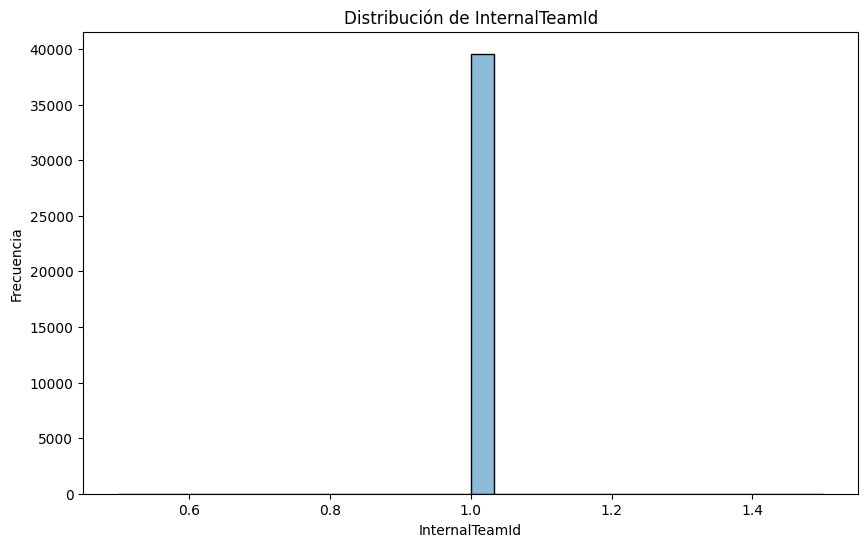

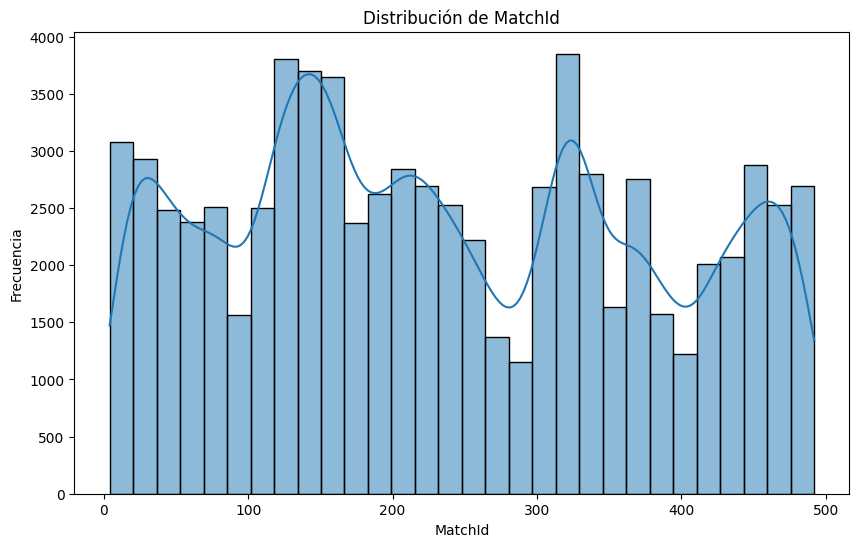

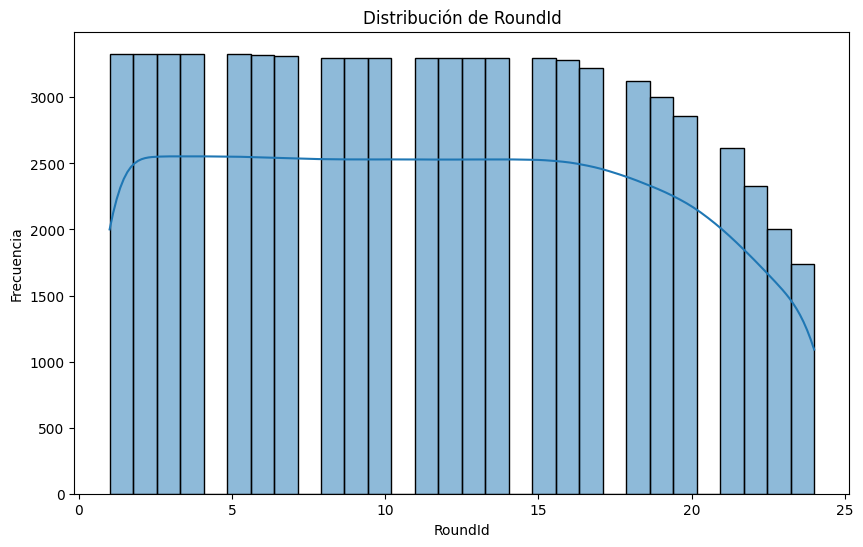

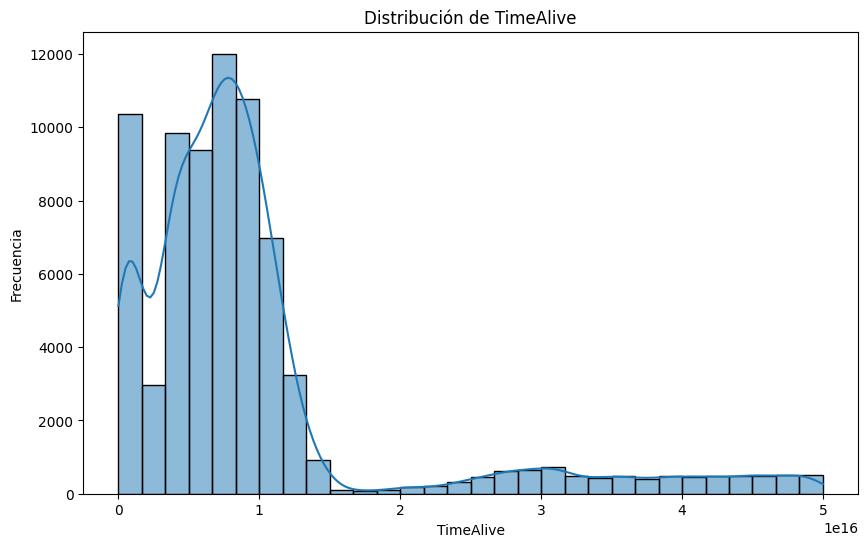

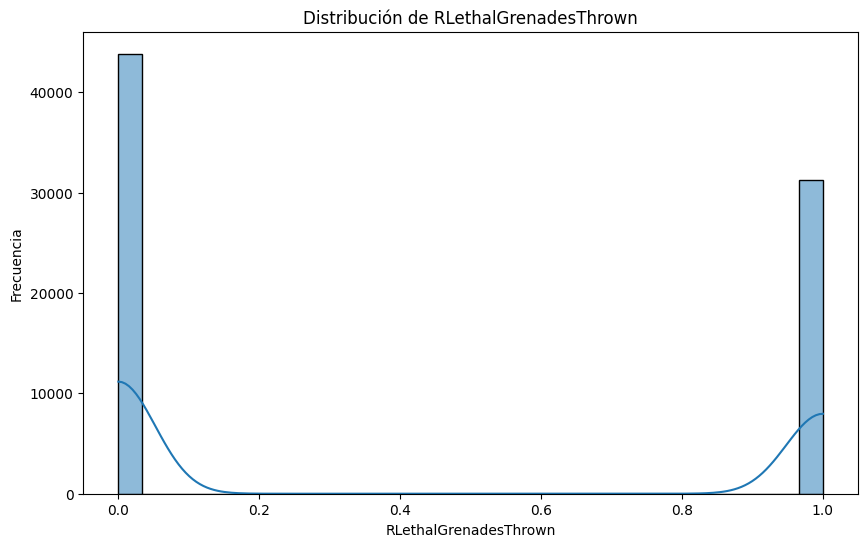

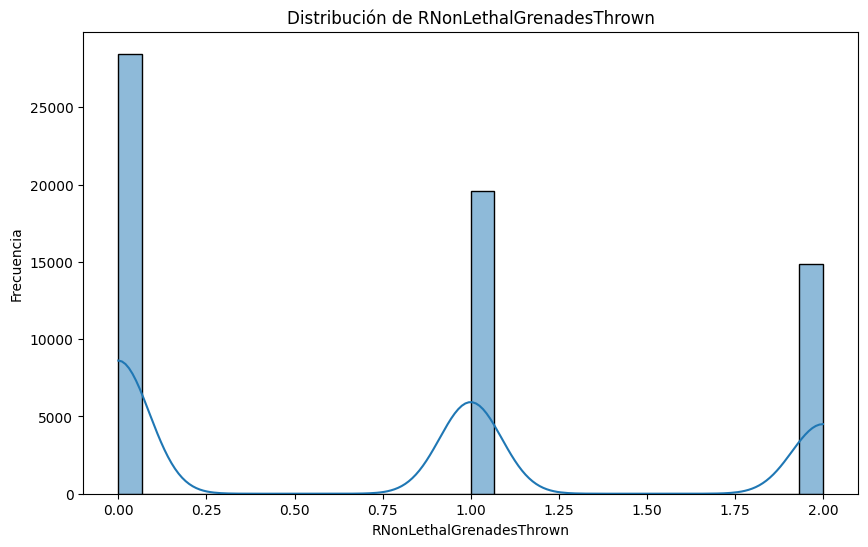

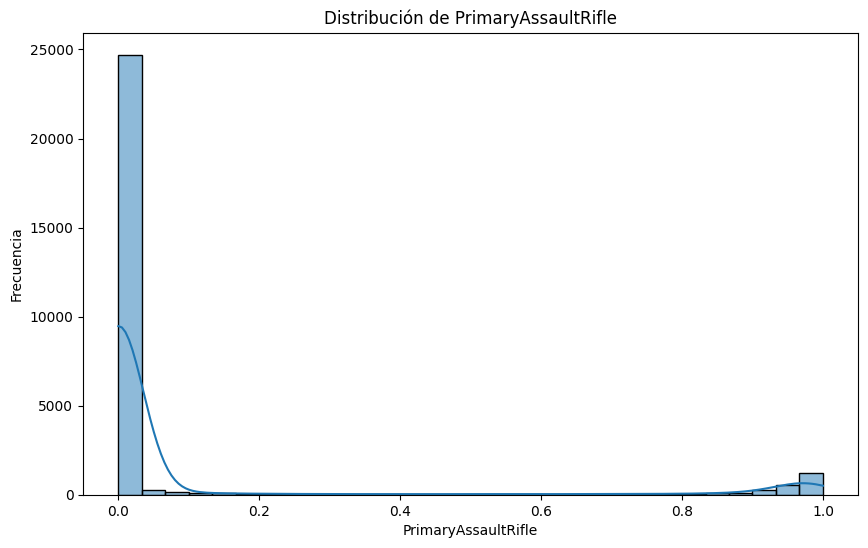

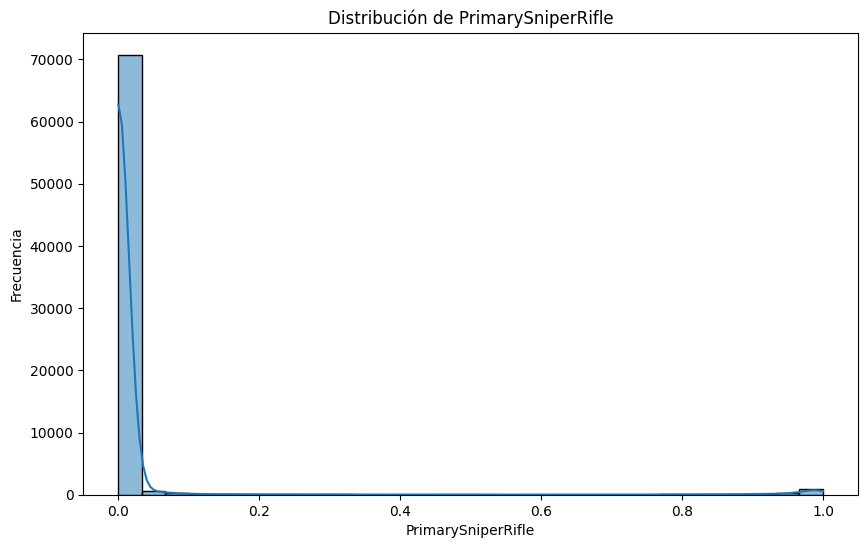

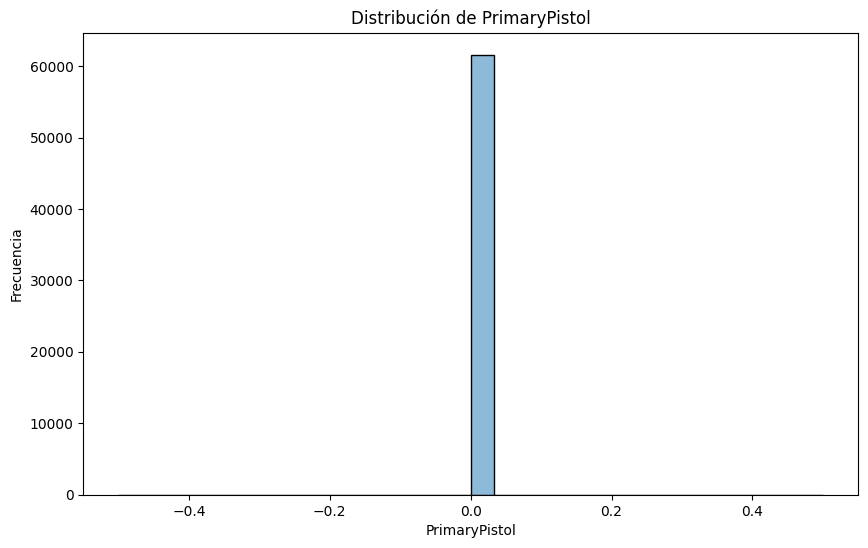

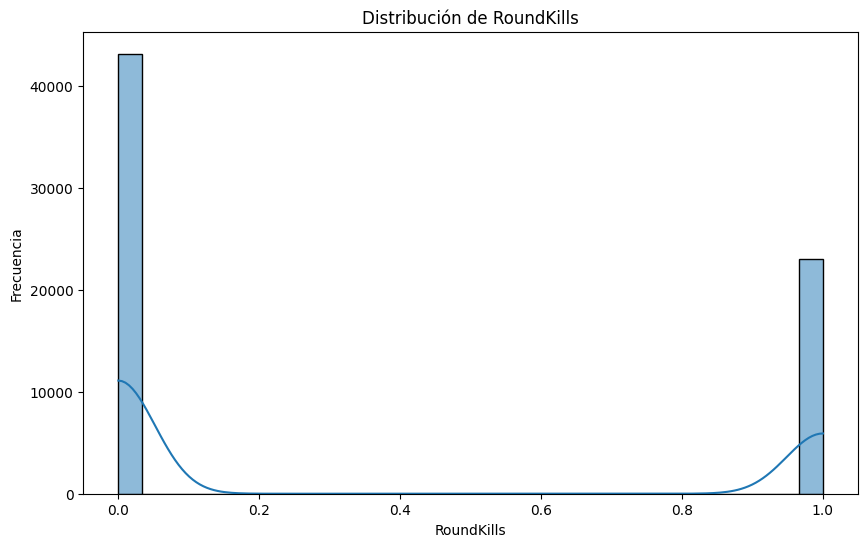

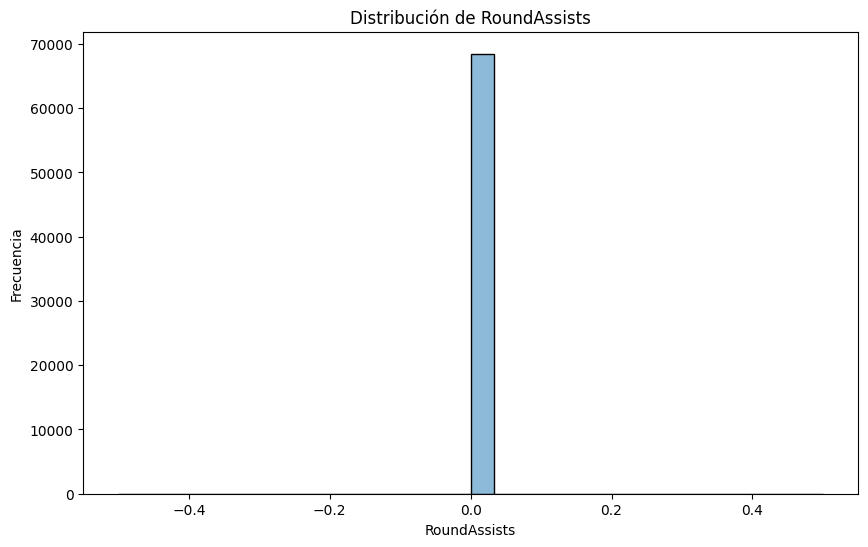

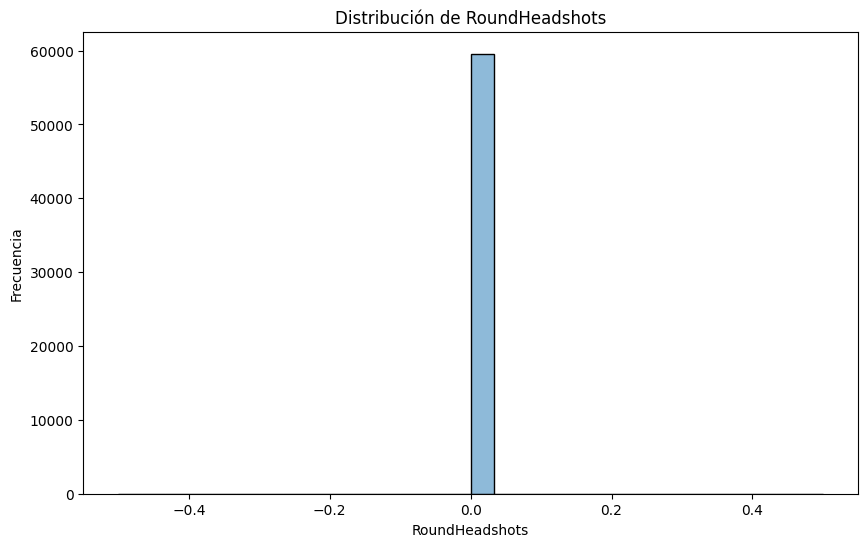

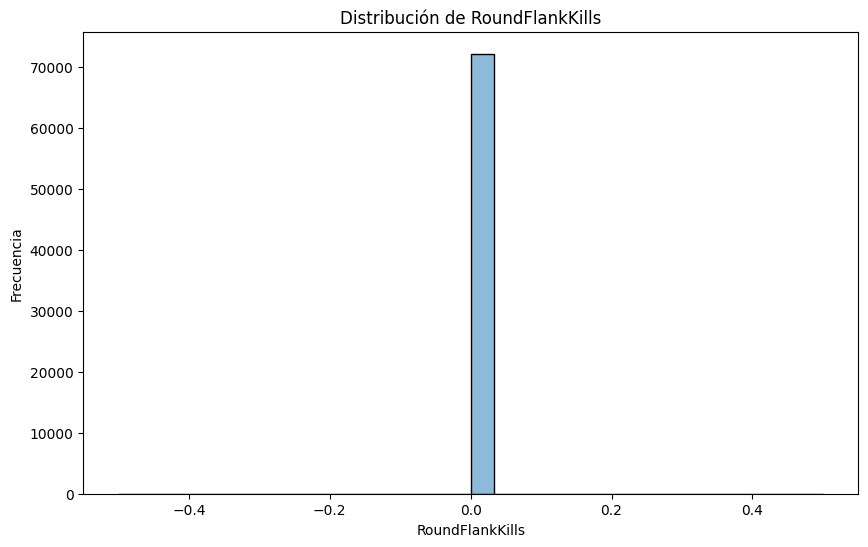

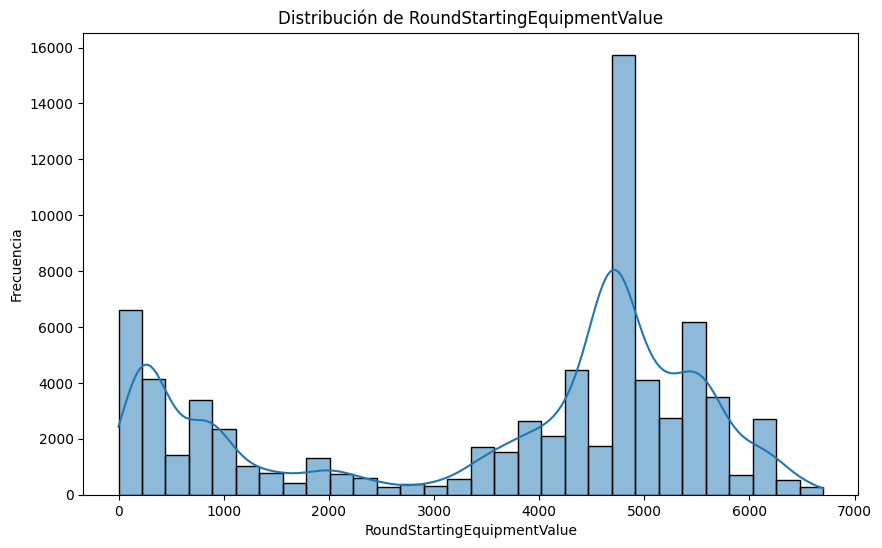

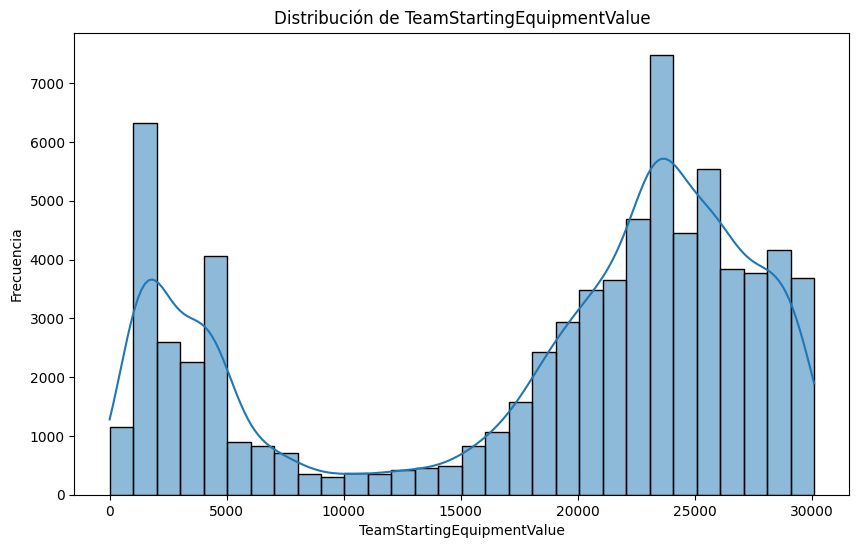

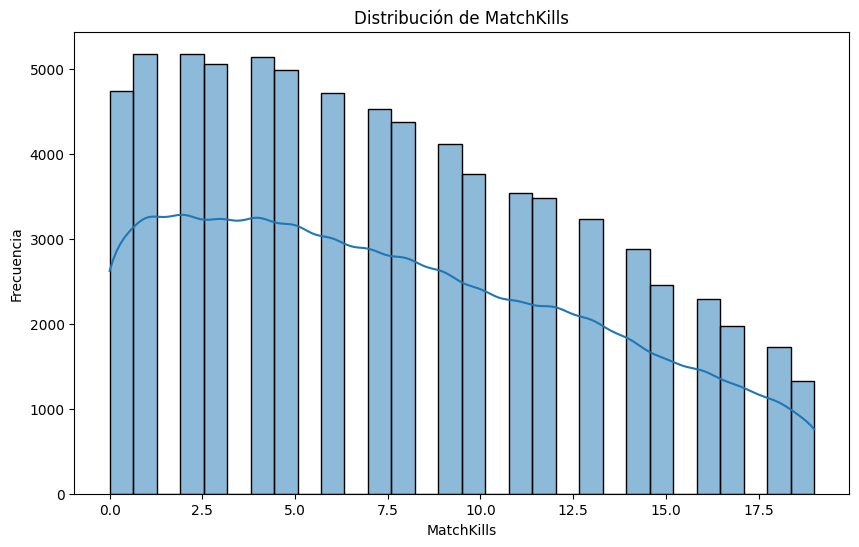

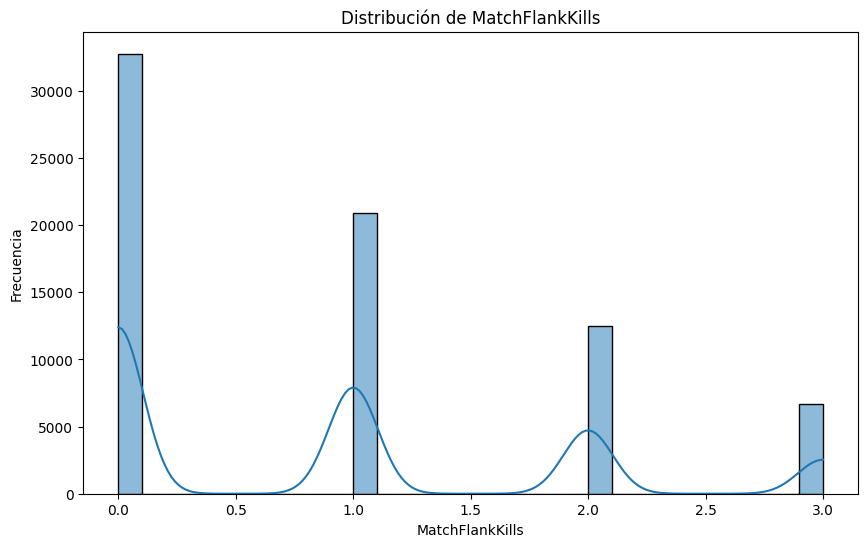

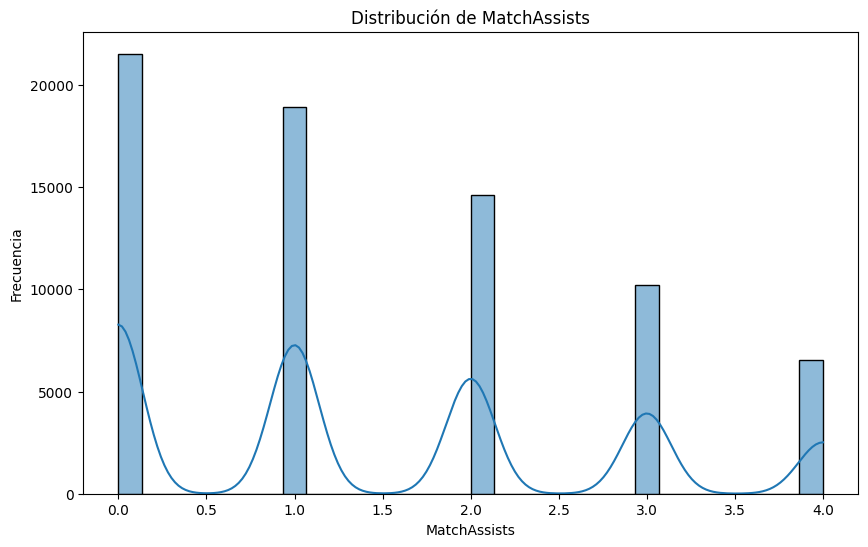

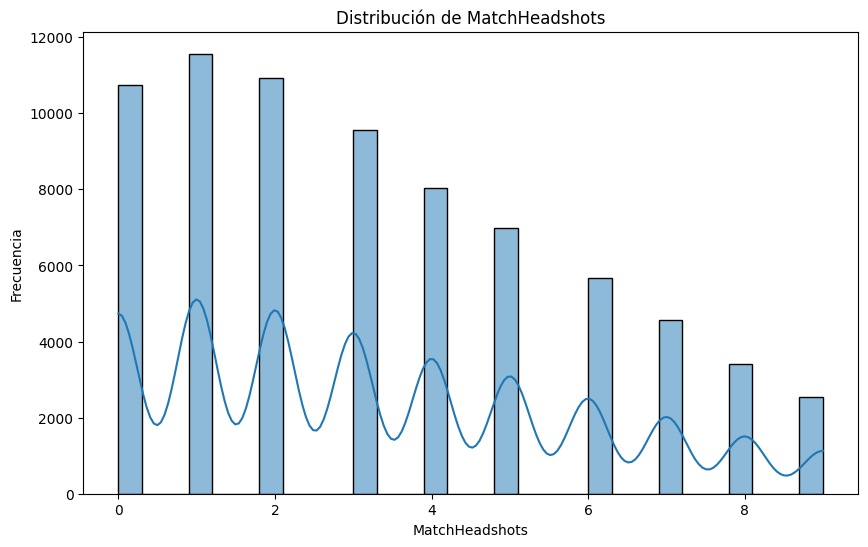

In [ ]:
# Eliminar 'Unnamed: 0' si existe
df = df.drop(columns=['Unnamed: 0'], errors='ignore')

# Tomamos una muestra aleatoria de 1000 filas para mejorar el rendimiento
sample_df = df.sample(n=1000, random_state=42)

# Variables numéricas en el dataset
numeric_vars = df.select_dtypes(include='number').columns

# Filtrar sólo variables que NO sean PrimarySMG ni PrimaryHeavy
vars_to_plot = [var for var in numeric_vars if var not in ['PrimarySMG', 'PrimaryHeavy']]

# Visualización de distribuciones para cada variable numérica relevante
for var in vars_to_plot:
    if var in df.columns:
        plt.figure(figsize=(10, 6))
        # Filtramos valores atípicos eliminando el 5% superior
        df_filtered = df[df[var] < df[var].quantile(0.95)]
        sns.histplot(df_filtered[var], bins=30, kde=True)
        plt.title(f'Distribución de {var}')
        plt.xlabel(var)
        plt.ylabel('Frecuencia')
        plt.show()


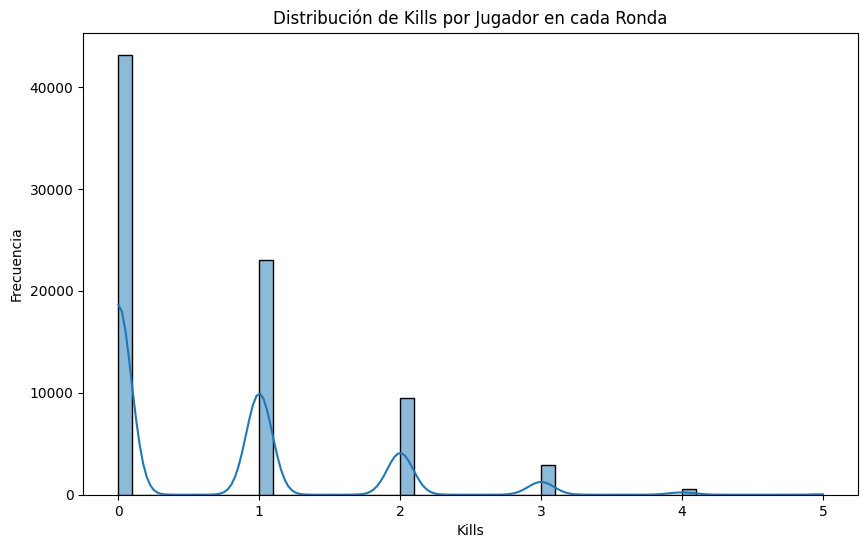

In [ ]:
# Analizar la distribución de Kills por jugador
plt.figure(figsize=(10, 6))
sns.histplot(df['RoundKills'], bins=50, kde=True)
plt.title('Distribución de Kills por Jugador en cada Ronda')
plt.xlabel('Kills')
plt.ylabel('Frecuencia')
plt.show()

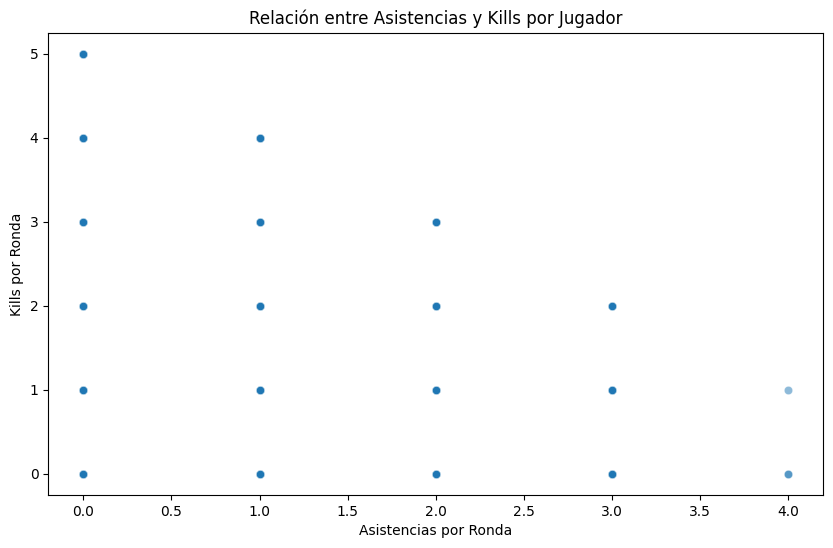

Correlación entre Asistencias y Kills: -0.021481967672222574


In [ ]:
# Relación entre Asistencias y Kills
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='RoundAssists', y='RoundKills', alpha=0.5)
plt.title('Relación entre Asistencias y Kills por Jugador')
plt.xlabel('Asistencias por Ronda')
plt.ylabel('Kills por Ronda')
plt.show()

# Calcular la correlación entre Asistencias y Kills
correlacion = df[['RoundAssists', 'RoundKills']].corr().iloc[0, 1]
print(f"Correlación entre Asistencias y Kills: {correlacion}")

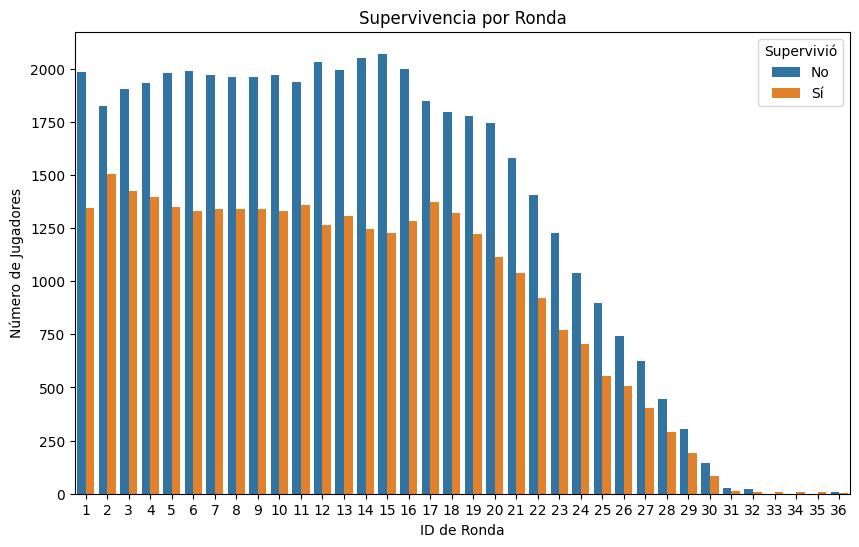

In [ ]:
# Analizar la relación entre la supervivencia y la ronda
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='RoundId', hue='Survived')
plt.title('Supervivencia por Ronda')
plt.xlabel('ID de Ronda')
plt.ylabel('Número de Jugadores')
plt.legend(title='Supervivió', loc='upper right', labels=['No', 'Sí'])
plt.show()

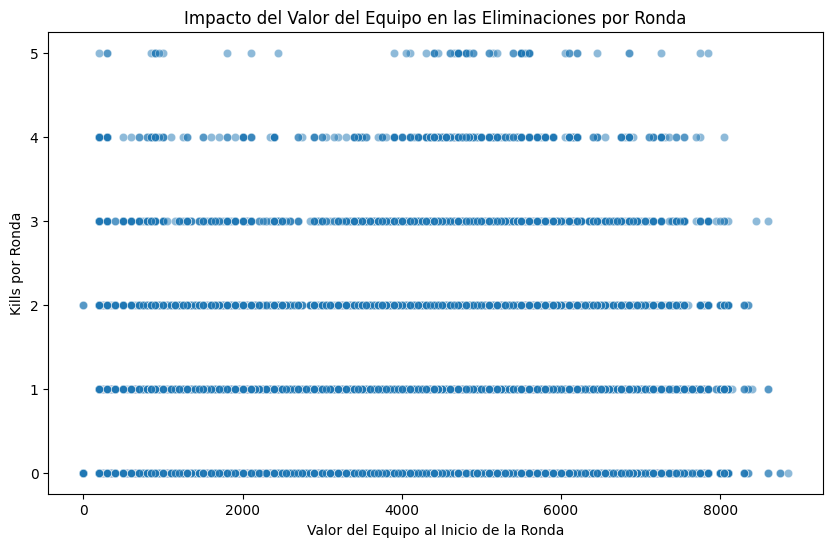

Correlación entre el Valor del Equipo y las Eliminaciones: 0.17214143826336517


In [ ]:
# Analizar el impacto del valor del equipo en las eliminaciones
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='RoundStartingEquipmentValue', y='RoundKills', alpha=0.5)
plt.title('Impacto del Valor del Equipo en las Eliminaciones por Ronda')
plt.xlabel('Valor del Equipo al Inicio de la Ronda')
plt.ylabel('Kills por Ronda')
plt.show()

# Calcular la correlación entre el valor del equipo y las eliminaciones
correlacion_equipo = df[['RoundStartingEquipmentValue', 'RoundKills']].corr().iloc[0, 1]
print(f"Correlación entre el Valor del Equipo y las Eliminaciones: {correlacion_equipo}")

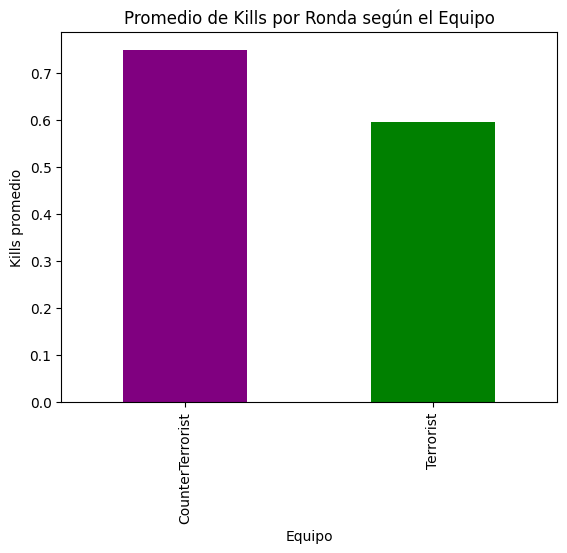

In [ ]:
# 7. Análisis de equipo
if 'RoundKills' in df.columns and 'Team' in df.columns:
    avg_kills = df.groupby('Team')['RoundKills'].mean()
    avg_kills.plot(kind='bar', color=['purple', 'green'])
    plt.title('Promedio de Kills por Ronda según el Equipo')
    plt.ylabel('Kills promedio')
    plt.xlabel('Equipo')
    plt.show()



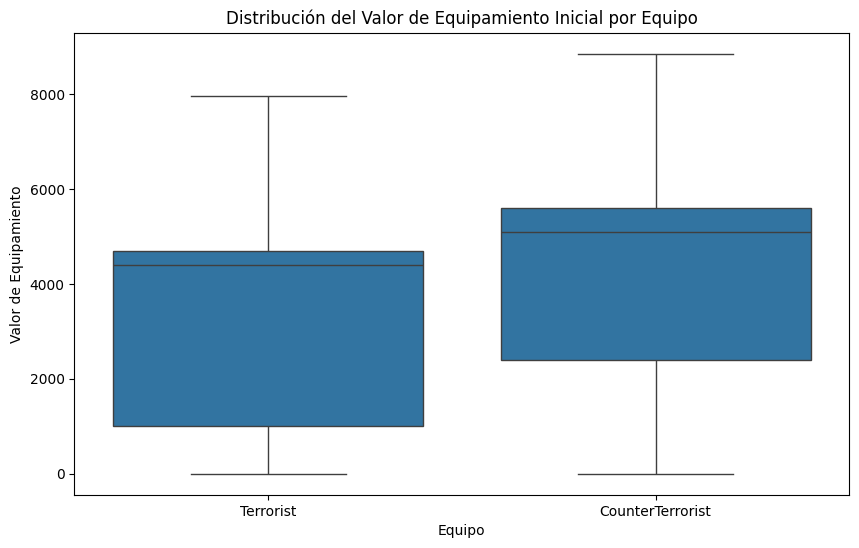

In [ ]:
if 'RoundStartingEquipmentValue' in df.columns and 'Team' in df.columns:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='Team', y='RoundStartingEquipmentValue', data=df)
    plt.title('Distribución del Valor de Equipamiento Inicial por Equipo')
    plt.xlabel('Equipo')
    plt.ylabel('Valor de Equipamiento')
    plt.show()



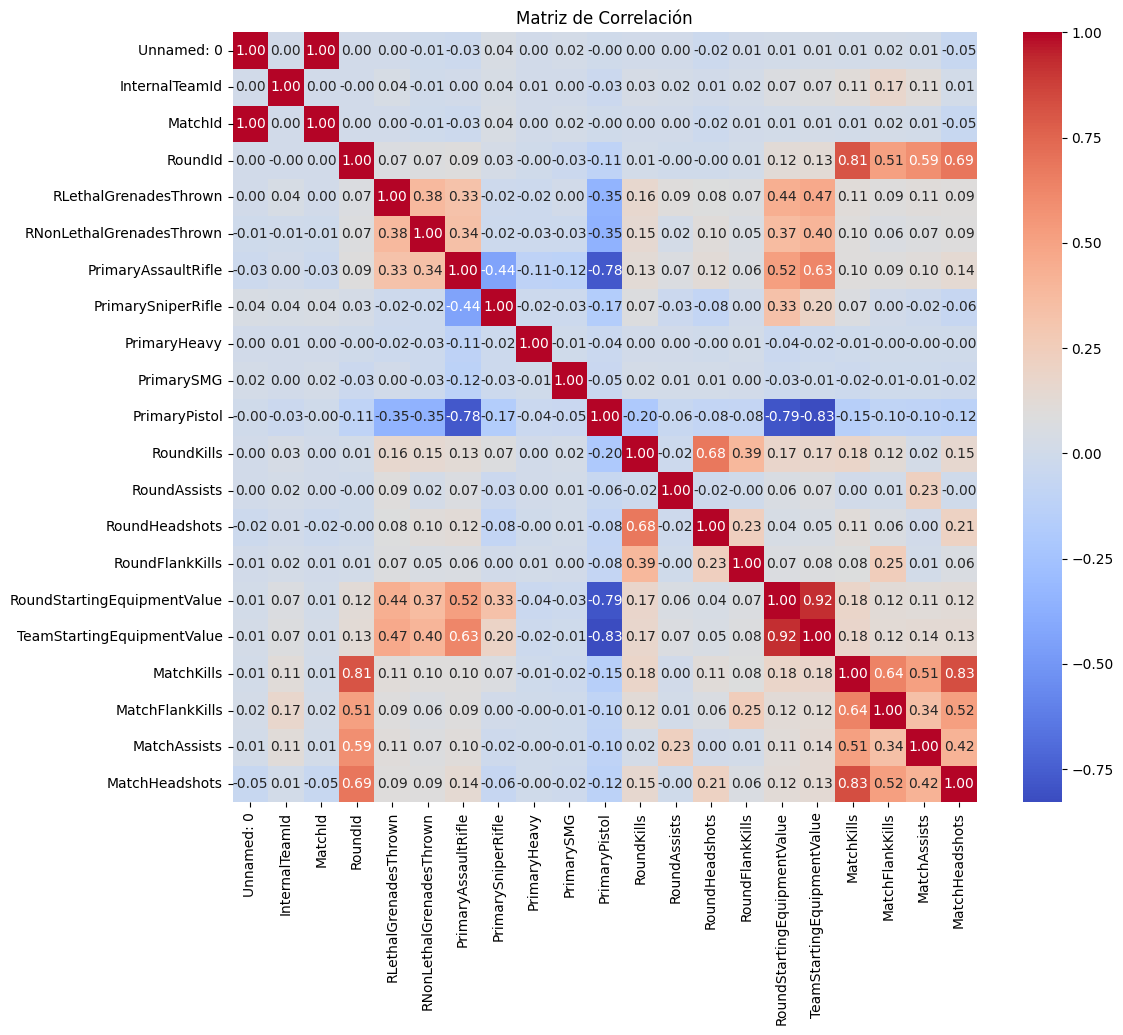

In [ ]:
# 8. Correlación entre variables numéricas
plt.figure(figsize=(12, 10))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Matriz de Correlación')
plt.show()

-------------- Pdero -----------------------


## Fase 2: Data Understanding

In [ ]:
# Estadísticos descriptivos para obtener medidas de posición y dispersión
descripcion = df.describe(include='all')  # Include all columns (numéricas y categóricas)
print("Estadísticos descriptivos:")
display(descripcion)

Estadísticos descriptivos:


,Map,Team,InternalTeamId,MatchId,RoundId,RoundWinner,MatchWinner,Survived,AbnormalMatch,TimeAlive,...,RoundKills,RoundAssists,RoundHeadshots,RoundFlankKills,RoundStartingEquipmentValue,TeamStartingEquipmentValue,MatchKills,MatchFlankKills,MatchAssists,MatchHeadshots
count,79157,79155,79157.000000,79157.000000,79157.000000,79157,79156,79157,79157,7.915700e+04,...,79157.000000,79157.000000,79157.000000,79157.000000,79157.000000,79157.000000,79157.000000,79157.000000,79157.000000,79157.000000
unique,4,2,NaN,NaN,NaN,3,2,2,1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,de_inferno,Terrorist,NaN,NaN,NaN,False,False,False,False,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,28869,39591,NaN,NaN,NaN,39588,42017,47214,79157,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,1.500006,250.525033,12.765517,NaN,NaN,NaN,NaN,1.213404e+16,...,0.671349,0.146178,0.301553,0.095633,3778.108695,18890.133532,8.511578,1.209912,1.874831,3.858484
std,NaN,NaN,0.500003,149.557804,7.432837,NaN,NaN,NaN,NaN,1.435118e+16,...,0.881798,0.385601,0.578843,0.320641,2111.285406,9743.203024,6.195079,1.435150,1.824027,3.246752
min,NaN,NaN,1.000000,4.000000,1.000000,NaN,NaN,NaN,NaN,0.000000e+00,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,NaN,NaN,1.000000,128.000000,6.000000,NaN,NaN,NaN,NaN,4.419176e+15,...,0.000000,0.000000,0.000000,0.000000,1600.000000,10900.000000,3.000000,0.000000,0.000000,1.000000
50%,NaN,NaN,2.000000,236.000000,12.000000,NaN,NaN,NaN,NaN,7.659978e+15,...,0.000000,0.000000,0.000000,0.000000,4700.000000,22550.000000,8.000000,1.000000,1.000000,3.000000
75%,NaN,NaN,2.000000,373.000000,19.000000,NaN,NaN,NaN,NaN,1.080375e+16,...,1.000000,0.000000,0.000000,0.000000,5200.000000,26050.000000,13.000000,2.000000,3.000000,6.000000


In [ ]:

# Seleccionar solo las columnas numéricas relevantes
numerical_cols = [
    'TimeAlive', 'TravelledDistance', 'RLethalGrenadesThrown', 'RNonLethalGrenadesThrown',
    'RoundKills', 'RoundAssists', 'RoundHeadshots', 'RoundFlankKills',
    'RoundStartingEquipmentValue', 'TeamStartingEquipmentValue', 'MatchKills',
    'MatchFlankKills', 'MatchAssists', 'MatchHeadshots'
]

# Filtrar solo las columnas numéricas
df_numerical = df[numerical_cols]





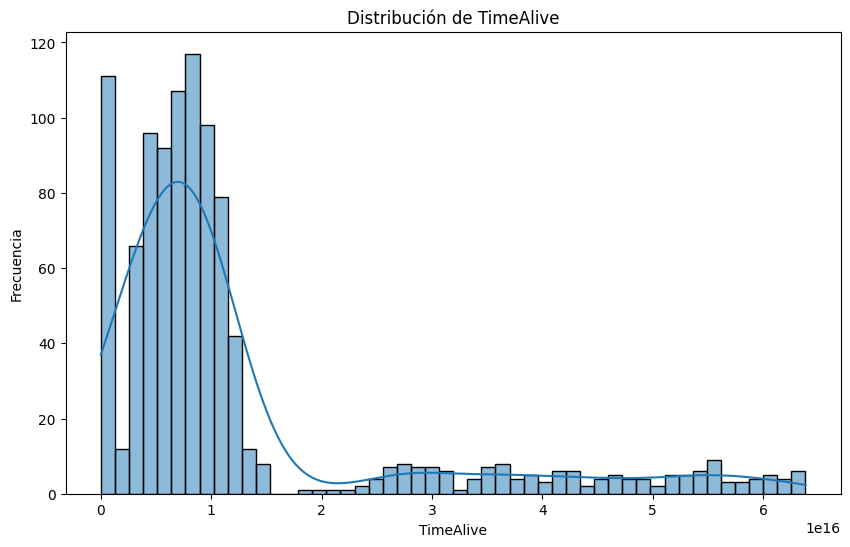

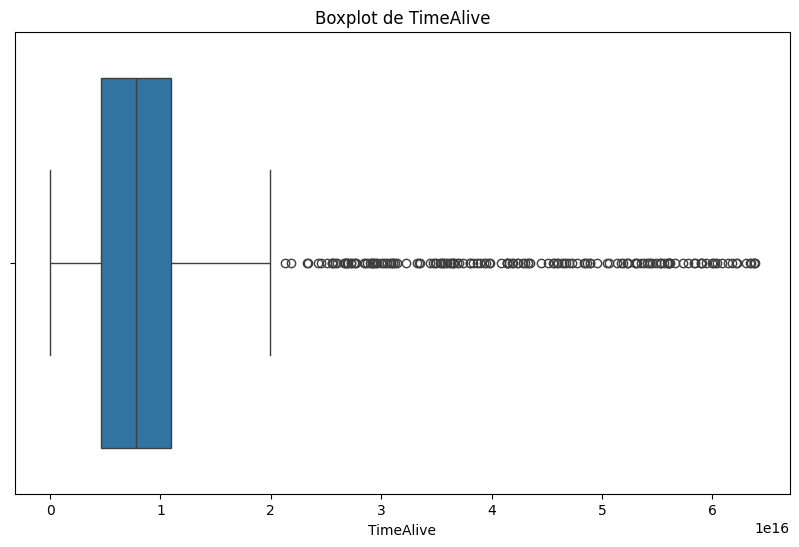

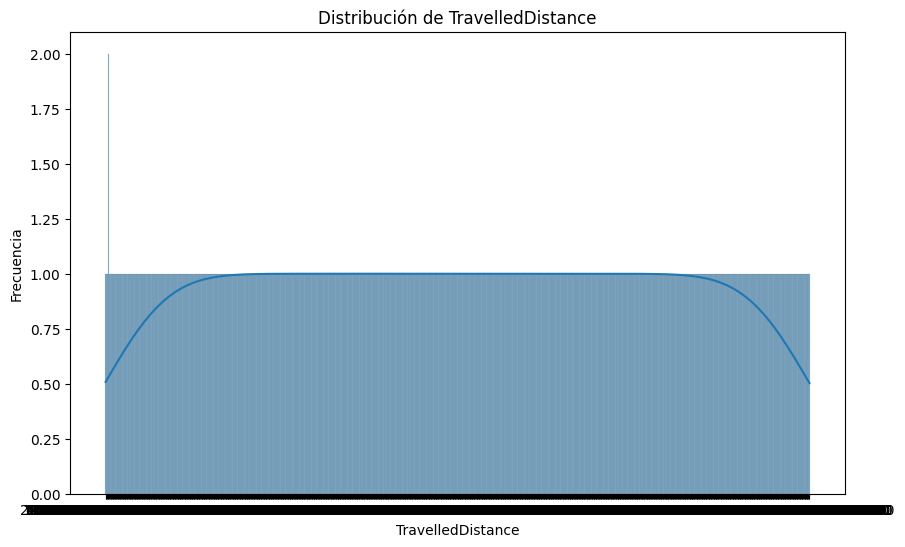

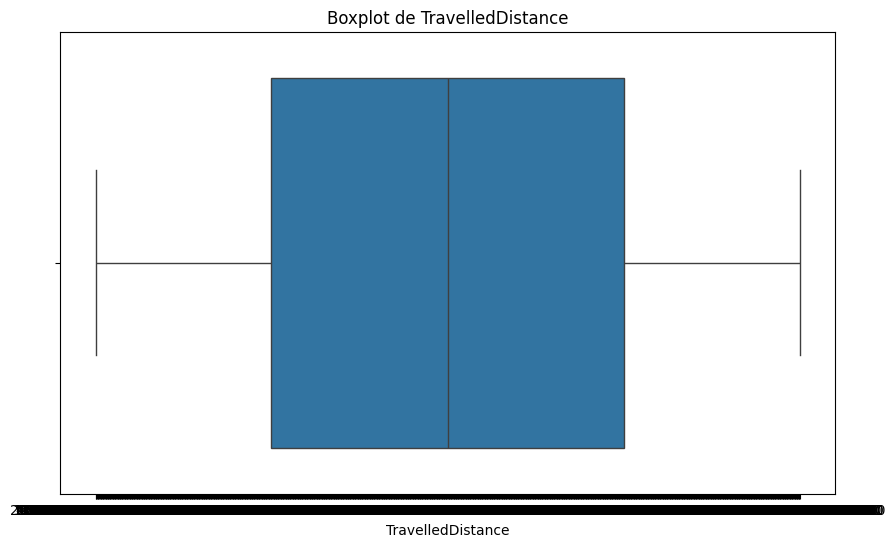

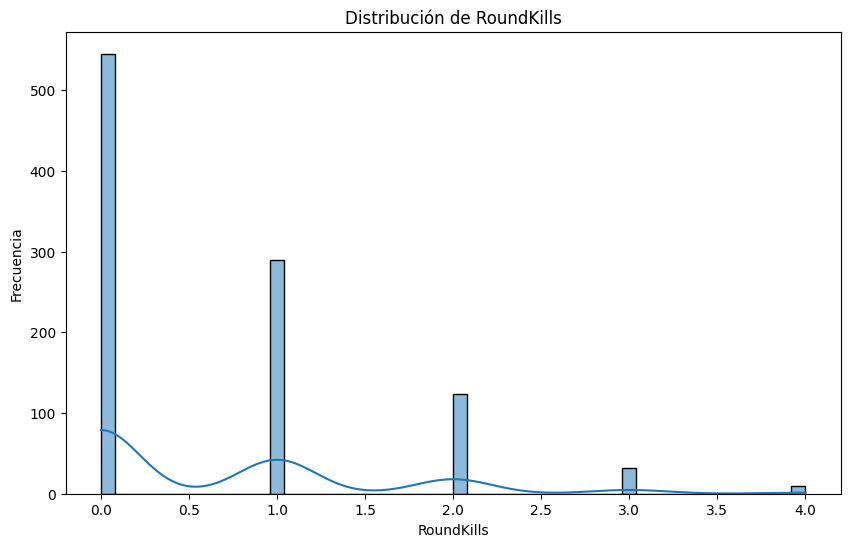

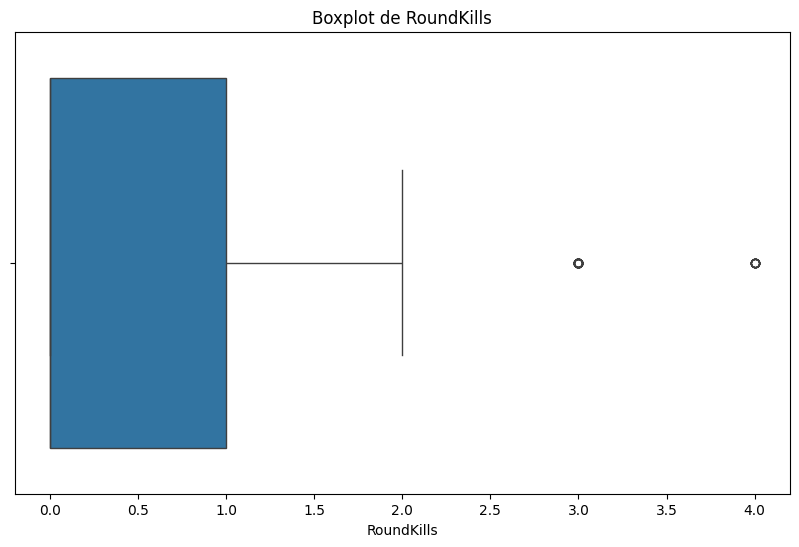

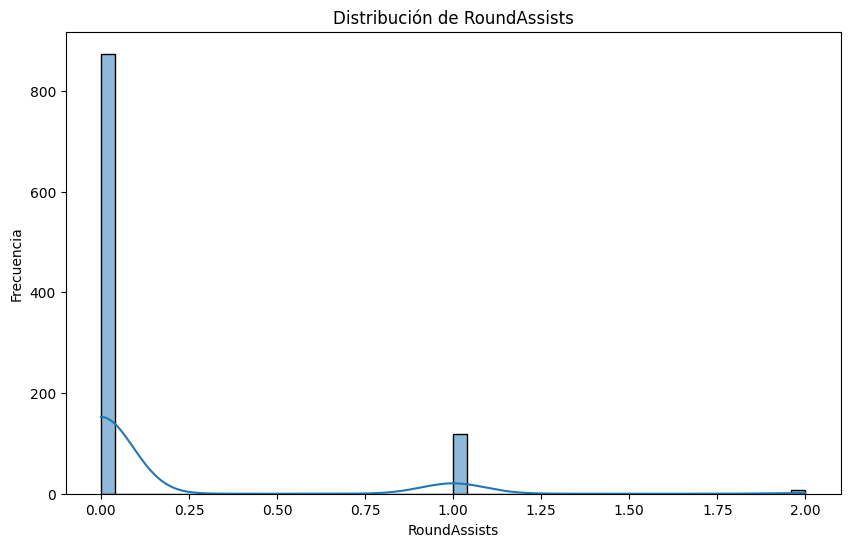

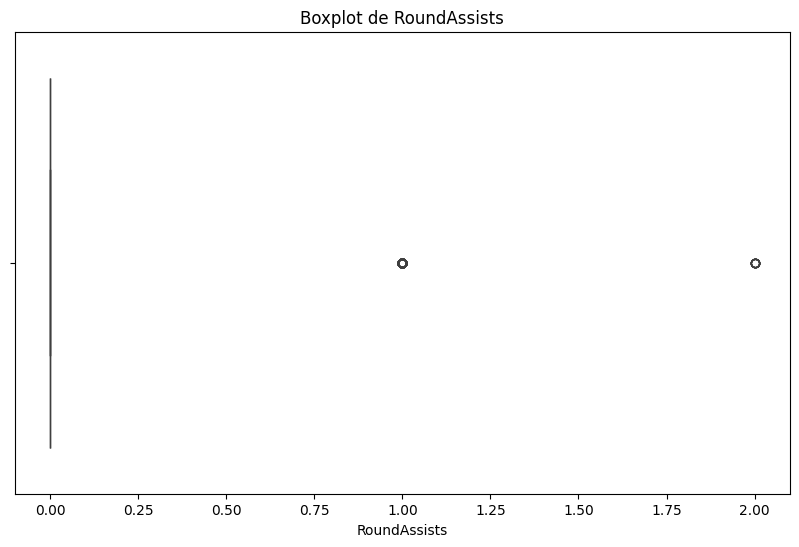

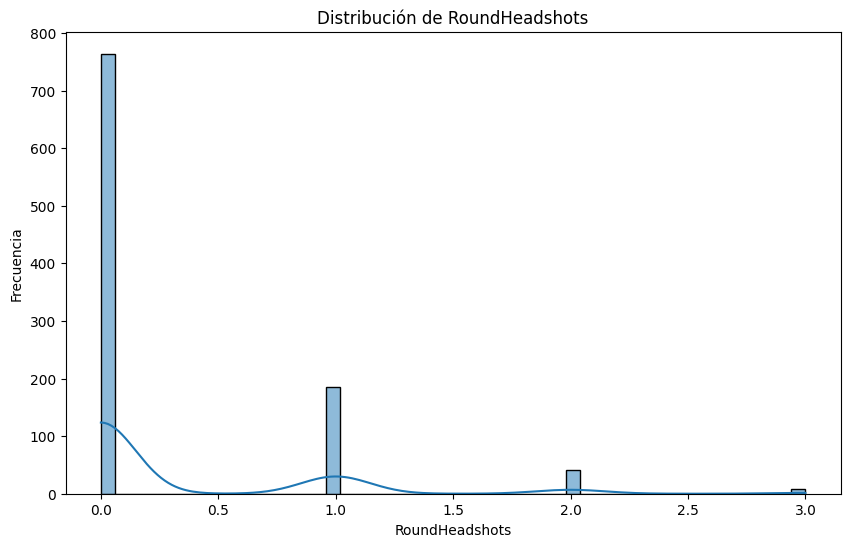

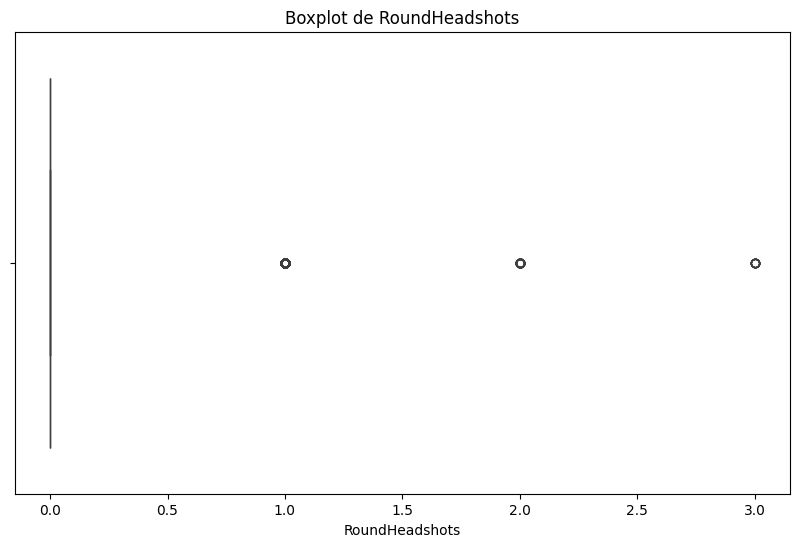

In [ ]:
# Tomamos una muestra aleatoria de 1000 filas para mejorar el rendimiento
df_sample = df.sample(n=1000, random_state=42)

numerical_vars = ['TimeAlive', 'TravelledDistance', 'RoundKills', 'RoundAssists', 'RoundHeadshots']
for var in numerical_vars:
    plt.figure(figsize=(10, 6))
    sns.histplot(df_sample[var], kde=True, bins=50)
    plt.title(f'Distribución de {var}')
    plt.xlabel(var)
    plt.ylabel('Frecuencia')
    plt.show()

    # Boxplot para ver la dispersión y posibles outliers
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=df_sample[var])
    plt.title(f'Boxplot de {var}')
    plt.xlabel(var)
    plt.show()


In [ ]:
# Asegurarse de que las columnas son numéricas (forzar conversión a numérico)
df['TimeAlive'] = pd.to_numeric(df['TimeAlive'], errors='coerce')
df['TravelledDistance'] = pd.to_numeric(df['TravelledDistance'], errors='coerce')

# Eliminar filas con valores nulos resultantes de la conversión (opcional)
df_cleaned = df.dropna(subset=['TimeAlive', 'TravelledDistance'])

# Medias, medianas, varianzas y desviaciones estándar de algunas variables numéricas
numerical_vars = ['TimeAlive', 'TravelledDistance']  # Puedes añadir más columnas aquí

for var in numerical_vars:
    print(f"\n{var}:")
    print(f"Media: {df_cleaned[var].mean()}")
    print(f"Mediana: {df_cleaned[var].median()}")
    print(f"Varianza: {df_cleaned[var].var()}")
    print(f"Desviación estándar: {df_cleaned[var].std()}")



TimeAlive:
Media: 8949704336342559.0
Mediana: 7611764699708130.0
Varianza: 1.038854062225029e+32
Desviación estándar: 1.0192419056460684e+16

TravelledDistance:
Media: 1184.3419879088278
Mediana: 0.0
Varianza: 152204963.6201706
Desviación estándar: 12337.137578067717


# 3. Data Preparation (Preparacion de los datos)

In [ ]:
# --- 1. Inspección de valores nulos ---
print("--- Inspección de valores nulos inicial ---")
null_counts = df.isnull().sum()
print("Número de valores nulos por columna:")
print(null_counts[null_counts > 0])

# --- 2. Tratamiento de valores nulos en columnas específicas ---
columnas_a_limpiar = ['TimeAlive', 'TravelledDistance']
print("\n--- Tratamiento de valores nulos en:", columnas_a_limpiar, "---")

# Forzar la conversión a numérico (maneja posibles errores convirtiendo no numéricos a NaN)
print("\nIntentando convertir a numérico:", columnas_a_limpiar)
df['TimeAlive'] = pd.to_numeric(df['TimeAlive'], errors='coerce')
df['TravelledDistance'] = pd.to_numeric(df['TravelledDistance'], errors='coerce')

# Contar los nuevos NaN introducidos por la conversión
nuevos_nulls = df[columnas_a_limpiar].isnull().sum()
print("\nNuevos valores nulos introducidos después de la conversión:")
print(nuevos_nulls[nuevos_nulls > 0])

# Eliminar las filas que tienen valores nulos en las columnas especificadas
df_clean = df.dropna(subset=columnas_a_limpiar).copy() # Usar .copy() para evitar SettingWithCopyWarning
print("\nNúmero de filas después de eliminar NaN en", columnas_a_limpiar, ":", len(df_clean))

# --- 3. Verificación final de valores nulos en las columnas limpiadas ---
print("\n--- Verificación final de valores nulos en:", columnas_a_limpiar, "---")
null_counts_clean = df_clean[columnas_a_limpiar].isnull().sum()
print("Número de valores nulos después de la limpieza:")
print(null_counts_clean[null_counts_clean > 0])

# --- 4. Cálculo de la correlación ---
print("\n--- Cálculo de la correlación ---")
correlation = df_clean[['TimeAlive', 'TravelledDistance']].corr().iloc[0, 1]
print("Correlación entre TimeAlive y TravelledDistance:", correlation)

# El DataFrame limpio ahora es 'df_clean'



--- Inspección de valores nulos inicial ---
Número de valores nulos por columna:
Team                     2
MatchWinner              1
TravelledDistance    78876
dtype: int64

--- Tratamiento de valores nulos en: ['TimeAlive', 'TravelledDistance'] ---

Intentando convertir a numérico: ['TimeAlive', 'TravelledDistance']

Nuevos valores nulos introducidos después de la conversión:
TravelledDistance    78876
dtype: int64

Número de filas después de eliminar NaN en ['TimeAlive', 'TravelledDistance'] : 281

--- Verificación final de valores nulos en: ['TimeAlive', 'TravelledDistance'] ---
Número de valores nulos después de la limpieza:
Series([], dtype: int64)

--- Cálculo de la correlación ---
Correlación entre TimeAlive y TravelledDistance: 0.1260410381034427


# 4. CONCLUSIONES

- Se realizó limpieza efectiva de datos outliers.
- Aplicamos estandarización y codificación de variables.
- Seleccionamos features relevantes para modelar.
- Datos listos para avanzar a fase de Modeling.










Y respondiendo alguna de las preguntas que realizamos anteriormente:


**¿Los equipos que realizan economía en la primera ronda tienen más probabilidades de ganar el partido completo? **

R: Realizar una ronda "eco" en la primera ronda implica comprar equipamiento mínimo para ahorrar dinero para las siguientes rondas. La correlación positiva muy débil (0.12) entre "RoundStartingEquipmentValue" (que sería bajo en una ronda eco) y "MatchWon" sugiere que los equipos que invierten más en equipamiento en la primera ronda tienen una ligera tendencia a ganar más partidas completas, esto podría deberse a obtener una ventaja inicial que se traduce en una economía más sólida a largo plazo.


**¿Realizar o no economía en la primera ronda influye significativamente en el rendimiento general? **

R: La decisión económica de la primera ronda en el rendimiento general (medido por las correlaciones con "MatchKills", "MatchAssists", "MatchHeadshots") parece ser pequeña pero positiva. Invertir más en la primera ronda podría llevar a una ligera ventaja en las estadísticas generales del equipo a lo largo del partido.
